In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [2]:
# Cell 1 — Load & Inspect Q25 Dataset

q25 = pd.read_csv(os.path.join(OUTPUT_PATH, "q25_pharma_doctor_ratio.csv"))

print(q25.shape)
print(q25.columns.tolist())
print(q25.dtypes)

# Normalize the expenditure column name in case it wasn't renamed during Phase 3 construction
if "value" in q25.columns and "catex_pct" not in q25.columns:
    q25 = q25.rename(columns={"value": "catex_pct"})

q25.head()

(149, 5)
['country', 'pharm_per_10k', 'doc_per_10k', 'pharm_doc_ratio', 'catex_pct']
country                str
pharm_per_10k      float64
doc_per_10k        float64
pharm_doc_ratio    float64
catex_pct          float64
dtype: object


,country,pharm_per_10k,doc_per_10k,pharm_doc_ratio,catex_pct
0,Benin,0.27,0.79,0.341772,10.92
1,Mozambique,0.10,0.84,0.119048,1.61
2,Namibia,2.44,4.18,0.583732,1.22
3,Nepal,3.95,7.49,0.527370,10.71
4,France,10.64,32.67,0.325681,1.42


In [3]:
# Cell 2 — Drop Rows With Missing Ratio (zero-doctor countries set to NaN in Phase 3)

q25_clean = q25.dropna(subset=["pharm_doc_ratio", "catex_pct"]).copy()
print(f"Countries available for correlation: {len(q25_clean)}")

Countries available for correlation: 149


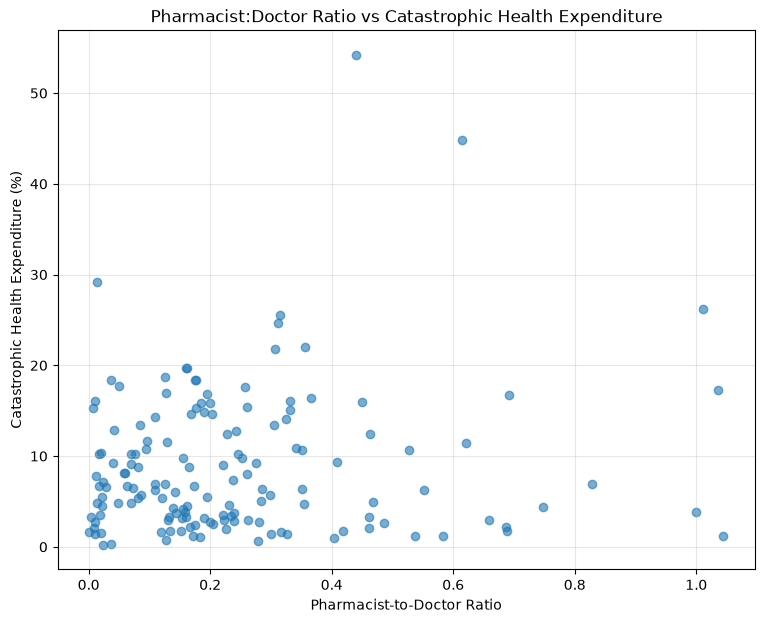

In [4]:
# Cell 3 — Scatter Plot: Pharmacist:Doctor Ratio vs Catastrophic Expenditure

plt.figure(figsize=(9, 7))
plt.scatter(q25_clean["pharm_doc_ratio"], q25_clean["catex_pct"], alpha=0.6)
plt.xlabel("Pharmacist-to-Doctor Ratio")
plt.ylabel("Catastrophic Health Expenditure (%)")
plt.title("Pharmacist:Doctor Ratio vs Catastrophic Health Expenditure")
plt.grid(alpha=0.3)
plt.show()

In [7]:
!pip3 install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 7.0 MB/s  0:00:02m0:00:0100:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
# Cell 4 — Correlation Strength (Pearson + Spearman, since ratio may be skewed/non-linear)
import scipy

pearson_r = q25_clean["pharm_doc_ratio"].corr(q25_clean["catex_pct"], method="pearson")
spearman_r = q25_clean["pharm_doc_ratio"].corr(q25_clean["catex_pct"], method="spearman")

print(f"Pearson correlation:  {pearson_r:.3f}")
print(f"Spearman correlation: {spearman_r:.3f}")

ModuleNotFoundError: No module named 'scipy'